In [1]:
import pandas as pd
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import Select
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException, TimeoutException
from io import StringIO
import re

def obter_pagina_atual(driver):
    """Lê o texto da paginação e retorna o número da página atual."""
    try:
        wait_curto = WebDriverWait(driver, 10)
        elem_paginacao = wait_curto.until(EC.presence_of_element_located((By.ID, 'lblPaginacion')))
        texto_paginacao = elem_paginacao.text
        match = re.search(r'Página\s+(\d+)', texto_paginacao)
        if match:
            return int(match.group(1))
        return -1
    except TimeoutException:
        print("Aviso: Não foi possível encontrar o indicador de página.")
        return -1
    except Exception as e:
        print(f"Aviso: Erro ao obter página atual: {e}")
        return -1

# --- 1. CONFIGURAÇÃO ---
print("Iniciando o WebDriver...")
driver = webdriver.Chrome()
driver.maximize_window()
print("WebDriver iniciado com sucesso.")

url = "https://www.economia-sniim.gob.mx/nuevo/Home.aspx?opcion=Consultas/MercadosNacionales/PreciosDeMercado/Agricolas/ConsultaFrutasYHortalizas.aspx?SubOpcion=4|0"
driver.get(url)
print("Página aberta.")
wait = WebDriverWait(driver, 60)

try:
    print("Entrando no iframe 'ifraHome'...")
    wait.until(EC.frame_to_be_available_and_switch_to_it((By.ID, "ifraHome")))
    print("Sucesso! Dentro do iframe.")
    
    print("Desativando a função de alerta para evitar interrupções...")
    driver.execute_script("window.alert = function() {};")
    print("Alertas desativados.")
    
    print("Preenchendo o formulário...")
    Select(wait.until(EC.presence_of_element_located((By.ID, 'ddlProducto')))).select_by_value('183')
    data_inicio = driver.find_element(By.ID, 'txtFechaInicio'); data_inicio.clear(); data_inicio.send_keys('01/01/2024')
    data_fim = driver.find_element(By.ID, 'txtFechaFinal'); data_fim.clear(); data_fim.send_keys('31/12/2024')
    Select(driver.find_element(By.ID, 'ddlPrecios')).select_by_value('2')
    print("Formulário preenchido.")
    
    driver.find_element(By.ID, 'btnBuscar').click()
    print("Botão 'Buscar' clicado.")

    print("Aguardando a tabela de resultados carregar...")
    wait.until(EC.presence_of_element_located((By.ID, 'tblResultados')))
    print("Tabela de resultados carregada com sucesso!")

except Exception as e:
    print(f"\nERRO CRÍTICO na configuração: {e}")
    if driver: driver.quit()
    raise SystemExit("Execução interrompida.")

# --- 2. EXTRAÇÃO E PAGINAÇÃO COM VERIFICAÇÃO DE ESTADO ---
lista_de_dataframes = []
total_paginas = 13
coleta_finalizada = False # Flag para controlar o loop externo

for pagina_alvo in range(1, total_paginas + 1):
    print("-" * 30)
    print(f"OBJETIVO: Chegar e extrair a página {pagina_alvo}.")
    
    tentativas = 0
    while True:
        try:
            pagina_atual = obter_pagina_atual(driver)
            print(f"Verificando... estamos na página {pagina_atual}.")

            if pagina_atual == pagina_alvo:
                print(f"Sucesso! Chegamos na página {pagina_alvo}. Extraindo dados...")
                tabela_element = wait.until(EC.visibility_of_element_located((By.ID, 'tblResultados')))
                html_string = tabela_element.get_attribute('outerHTML')
                df_pagina = pd.read_html(StringIO(html_string))[0]
                lista_de_dataframes.append(df_pagina)
                print(f"Página {pagina_alvo} extraída.")
                
                if pagina_alvo == total_paginas:
                    print("Última página extraída. Finalizando a coleta.")
                    coleta_finalizada = True
                    break
                
                driver.find_element(By.ID, 'ibtnSiguiente').click()
                time.sleep(4)
                break
            else:
                print(f"Página errada. Clicando em 'Siguiente' para tentar chegar na página {pagina_alvo}...")
                driver.find_element(By.ID, 'ibtnSiguiente').click()
                time.sleep(4)
            
            tentativas += 1
            if tentativas > 25: # Trava de segurança
                print("Muitas tentativas para chegar na página correta. Abortando.")
                coleta_finalizada = True
                break

        except (NoSuchElementException, TimeoutException):
            print("Fim da paginação (botão 'Siguiente' não encontrado ou página travou).")
            coleta_finalizada = True
            break
        except Exception as e:
            print(f"Um erro inesperado ocorreu: {e}")
            coleta_finalizada = True
            break
            
    if coleta_finalizada:
        break # Quebra o loop 'for' principal

# --- 3. CONSOLIDAÇÃO E SALVAMENTO ---
if lista_de_dataframes:
    print("\nConsolidando todos os dataframes...")
    df_final = pd.concat(lista_de_dataframes, ignore_index=True)
    df_final.columns = df_final.iloc[0]
    df_final = df_final[1:].reset_index(drop=True)
    df_final = df_final[df_final['Fecha'].notna()]
    df_final.reset_index(drop=True, inplace=True)
    caminho_do_arquivo = r"C:\Users\lucas\Downloads\Case Bradesco\dados_cebola_sniim.csv"# <-- Alterar caminho
    df_final.to_csv(caminho_do_arquivo, index=False, encoding='utf-8-sig')
    print("-" * 50)    
    print(f"Os dados foram salvos em '{caminho_do_arquivo}' com {len(df_final)} linhas.")
    print("\nAmostra dos dados:")
    print(df_final.head())
    print("-" * 50)
else:
    print("Nenhum dado foi extraído.")

# --- 4. FINALIZAÇÃO ---
print("\nFechando o navegador.")
driver.quit()

Iniciando o WebDriver...
WebDriver iniciado com sucesso.
Página aberta.
Entrando no iframe 'ifraHome'...
Sucesso! Dentro do iframe.
Desativando a função de alerta para evitar interrupções...
Alertas desativados.
Preenchendo o formulário...
Formulário preenchido.
Botão 'Buscar' clicado.
Aguardando a tabela de resultados carregar...
Tabela de resultados carregada com sucesso!
------------------------------
OBJETIVO: Chegar e extrair a página 1.
Verificando... estamos na página 1.
Sucesso! Chegamos na página 1. Extraindo dados...
Página 1 extraída.
------------------------------
OBJETIVO: Chegar e extrair a página 2.
Verificando... estamos na página 2.
Sucesso! Chegamos na página 2. Extraindo dados...
Página 2 extraída.
------------------------------
OBJETIVO: Chegar e extrair a página 3.
Aviso: Erro ao obter página atual: Alert Text: No hay mas páginas
Message: unexpected alert open: {Alert text : No hay mas páginas}
  (Session info: chrome=141.0.7390.66)
Stacktrace:
	GetHandleVerifier [

In [2]:
# Parte 2 completa (limpeza robusta + regressão sem intercepto) com visualizações intermediárias

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display

# --- caminhos ---
dados_path = r"C:\Users\lucas\Downloads\Case Bradesco\dados_cebola_sniim.csv"# <-- Alterar caminho
inflacao_path = r"C:\Users\lucas\Downloads\Case Bradesco\inflacao_cebola.xlsx"# <-- Alterar caminho

# --- 1. leitura ---
print("--- 1. Lendo os arquivos originais... ---")
df = pd.read_csv(dados_path)
inflacao_ref_original = pd.read_excel(inflacao_path, sheet_name="Planilha1")
print("Arquivos carregados com sucesso.\n")

# INSERIDO PARA VISUALIZAÇÃO
print("Amostra dos dados raspados (brutos):")
display(df.head())
print("\nAmostra da inflação de referência (bruta):")
display(inflacao_ref_original.head())

# tenta detectar coluna de inflação automaticamente (procura 'infl' em nome)
col_inf = next((c for c in inflacao_ref_original.columns if "infl" in c.lower()), inflacao_ref_original.columns[1])
inflacao_ref = inflacao_ref_original[[col_inf]].rename(columns={col_inf: "y"}).reset_index(drop=True)
print(f"\nColuna de inflação de referência detectada: '{col_inf}'\n")

--- 1. Lendo os arquivos originais... ---
Arquivos carregados com sucesso.

Amostra dos dados raspados (brutos):


,Fecha,Presentación,Origen,Destino,Precio Mín,Precio Max,Precio Frec,Obs.
0,Hortalizas,Hortalizas,Hortalizas,Hortalizas,Hortalizas,Hortalizas,Hortalizas,Hortalizas
1,02/01/2024,Kilogramo,Guanajuato,Aguascalientes: Centro Comercial Agropecuario ...,8.00,10.00,9.00,NaN
2,03/01/2024,Kilogramo,Guanajuato,Aguascalientes: Centro Comercial Agropecuario ...,8.00,10.00,9.00,NaN
3,04/01/2024,Kilogramo,Guanajuato,Aguascalientes: Centro Comercial Agropecuario ...,8.00,10.00,9.00,NaN
4,05/01/2024,Kilogramo,Guanajuato,Aguascalientes: Centro Comercial Agropecuario ...,8.00,10.00,9.00,NaN



Amostra da inflação de referência (bruta):


,quinzena,inflacao
0,2024-01-01,0.071607
1,2024-01-31,0.023535
2,2024-02-01,0.064196
3,2024-02-28,0.018317
4,2024-03-01,-0.160447



Coluna de inflação de referência detectada: 'inflacao'



In [3]:
# --- 2. limpeza básica dos dados raspados ---
print("--- 2. Limpando os dados raspados... ---")
expected_cols = ["Fecha", "Presentación", "Precio Frec"]
for c in expected_cols:
    if c not in df.columns:
        raise ValueError(f"Coluna esperada não encontrada no CSV: {c}")
df = df[expected_cols].copy()

df["Fecha"] = pd.to_datetime(df["Fecha"], format="%d/%m/%Y", errors="coerce")
df["Precio Frec"] = pd.to_numeric(df["Precio Frec"].astype(str).str.replace(",", "."), errors="coerce")
df["Presentación"] = df["Presentación"].astype(str).str.strip()

df = df.dropna(subset=["Fecha", "Precio Frec"])
print(f"Base de dados após limpeza: {len(df)} observações.\n")

# INSERIDO PARA VISUALIZAÇÃO
print("Amostra dos dados raspados (após limpeza):")
display(df.head())
print("\nVerificação dos tipos de dados:")
df.info()

--- 2. Limpando os dados raspados... ---
Base de dados após limpeza: 6397 observações.

Amostra dos dados raspados (após limpeza):


,Fecha,Presentación,Precio Frec
1,2024-01-02,Kilogramo,9.0
2,2024-01-03,Kilogramo,9.0
3,2024-01-04,Kilogramo,9.0
4,2024-01-05,Kilogramo,9.0
5,2024-01-08,Kilogramo,9.0



Verificação dos tipos de dados:
<class 'pandas.core.frame.DataFrame'>
Index: 6397 entries, 1 to 6421
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Fecha         6397 non-null   datetime64[ns]
 1   Presentación  6397 non-null   object        
 2   Precio Frec   6397 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 199.9+ KB


In [4]:
# --- 3. cria quinzena e agrega média quinzenal ---
print("\n--- 3. Agrupando preços por quinzena... ---")
def quinzena_label(d):
    return f"{d.year}-{d.month:02d}-Q{1 if d.day <= 15 else 2}"
df["quinzena"] = df["Fecha"].apply(quinzena_label)
df_quinz = df.groupby(["Presentación", "quinzena"], as_index=False)["Precio Frec"].mean()
print("Preços médios por quinzena calculados.\n")

# --- 4. calcula inflação quinzenal por apresentação ---
print("--- 4. Calculando a inflação para cada 'Presentación'... ---")
df_quinz = df_quinz.sort_values(["Presentación", "quinzena"])
df_quinz["inflacao"] = df_quinz.groupby("Presentación")["Precio Frec"].pct_change()
df_quinz = df_quinz.dropna(subset=["inflacao"]).reset_index(drop=True)
print(f"Observações quinzenais com inflação calculada: {len(df_quinz)}\n")

# --- 5. pivot para formato wide (variáveis X) ---
print("--- 5. Criando a tabela de variáveis X (inflação por 'Presentación')... ---")
df_wide = df_quinz.pivot(index="quinzena", columns="Presentación", values="inflacao")
df_wide = df_wide.sort_index()

# INSERIDO PARA VISUALIZAÇÃO
print("Amostra da tabela de inflação quinzenal (formato wide):")
display(df_wide.head())

# --- 6. alinhar inflação de referência com as quinzenas ---
print("\n--- 6. Alinhando as séries X e Y... ---")
n_obs = len(df_wide)
if len(inflacao_ref) < n_obs:
    raise ValueError(f"A série de inflação de referência tem {len(inflacao_ref)} observações, menor que {n_obs} (necessárias). Ajuste o arquivo.")
y_series = inflacao_ref.iloc[-n_obs:].reset_index(drop=True)["y"].astype(float)
df_wide_reset = df_wide.reset_index(drop=True)
df_modelo = pd.concat([y_series, df_wide_reset], axis=1)
df_modelo = df_modelo.rename(columns={"y": "y"})
print(f"Série para modelo criada com {df_modelo.shape[0]} observações.\n")


# INSERIDO PARA VISUALIZAÇÃO
print("Amostra do dataframe final que será usado no modelo (X e Y alinhados):")
display(df_modelo.head())


# --- 7. limpeza final das variáveis explicativas ---
# (As saídas de texto desta seção já são bem descritivas, então foram mantidas como no original)
print("\n--- 7. Realizando limpeza final no dataframe do modelo... ---")
X = df_modelo.drop(columns=["y"]).apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df_modelo["y"], errors="coerce")
nan_cols = X.columns[X.isna().all()].tolist()
if nan_cols:
    print(f"Removendo colunas com todos NaN: {nan_cols}")
    X = X.drop(columns=nan_cols)
const_cols = [c for c in X.columns if X[c].dropna().std() == 0 or X[c].dropna().shape[0]==0]
if const_cols:
    print(f"Removendo colunas constantes (var=0): {const_cols}")
    X = X.drop(columns=const_cols)
non_numeric = X.columns[X.dtypes == "object"].tolist()
if non_numeric:
    print(f"Convertendo colunas object -> numeric (forçando NaN onde não converte): {non_numeric}")
    X[non_numeric] = X[non_numeric].apply(pd.to_numeric, errors="coerce")
mask = X.notna().all(axis=1) & y.notna()
X_clean = X[mask].reset_index(drop=True)
y_clean = y[mask].reset_index(drop=True)
print(f"Após limpeza: {len(y_clean)} observações e {X_clean.shape[1]} variáveis explicativas usadas na regressão.\n")


if X_clean.shape[1] == 0 or len(y_clean) == 0:
    raise ValueError("Não há variáveis explicativas válidas ou não há observações suficientes após limpeza.")

# --- 8. checagem multicolinearidade / condicionamento ---
print("--- 8. Checando multicolinearidade... ---")
cond_no = np.linalg.cond(X_clean.fillna(0).values)
print(f"Condition number before check: {cond_no:.2e}")
if cond_no > 1e12:
    print("Condition number muito alto -> removendo colunas com alta correlação pairwise (threshold 0.995).")
    corr = X_clean.corr().abs()
    to_drop = set()
    for i in corr.columns:
        for j in corr.columns:
            if i!=j and corr.loc[i,j] > 0.995:
                to_drop.add(j)
    if to_drop:
        print(f"Removendo colunas altamente correlacionadas: {sorted(list(to_drop))}")
        X_clean = X_clean.drop(columns=list(to_drop))
    cond_no = np.linalg.cond(X_clean.fillna(0).values)
    print(f"Condition number after drop: {cond_no:.2e}")


--- 3. Agrupando preços por quinzena... ---
Preços médios por quinzena calculados.

--- 4. Calculando a inflação para cada 'Presentación'... ---
Observações quinzenais com inflação calculada: 46

--- 5. Criando a tabela de variáveis X (inflação por 'Presentación')... ---
Amostra da tabela de inflação quinzenal (formato wide):


Presentación,Arpilla de 30 kg.,Kilogramo
quinzena,,
2024-01-Q2,0.082348,0.057510
2024-02-Q1,0.095804,0.043782
2024-02-Q2,-0.050951,-0.018177
2024-03-Q1,-0.248271,-0.196309
2024-03-Q2,-0.136956,-0.154820



--- 6. Alinhando as séries X e Y... ---
Série para modelo criada com 23 observações.

Amostra do dataframe final que será usado no modelo (X e Y alinhados):


,y,Arpilla de 30 kg.,Kilogramo
0,0.023535,0.082348,0.057510
1,0.064196,0.095804,0.043782
2,0.018317,-0.050951,-0.018177
3,-0.160447,-0.248271,-0.196309
4,-0.108805,-0.136956,-0.154820



--- 7. Realizando limpeza final no dataframe do modelo... ---
Após limpeza: 23 observações e 2 variáveis explicativas usadas na regressão.

--- 8. Checando multicolinearidade... ---
Condition number before check: 3.72e+00


In [5]:
# --- 9. regressão OLS sem intercepto ---
print("\n--- 9. Rodando OLS (sem intercepto)... ---")
modelo = sm.OLS(y_clean, X_clean.fillna(0)).fit()

print("\n================ RESULTADOS DA REGRESSÃO ================")
print(modelo.summary())


--- 9. Rodando OLS (sem intercepto)... ---

================ RESULTADOS DA REGRESSÃO ================
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.922
Model:                            OLS   Adj. R-squared (uncentered):              0.915
Method:                 Least Squares   F-statistic:                              124.0
Date:                Mon, 13 Oct 2025   Prob (F-statistic):                    2.35e-12
Time:                        10:36:00   Log-Likelihood:                          49.066
No. Observations:                  23   AIC:                                     -94.13
Df Residuals:                      21   BIC:                                     -91.86
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 


--- 10. Gerando gráfico de resultados... ---


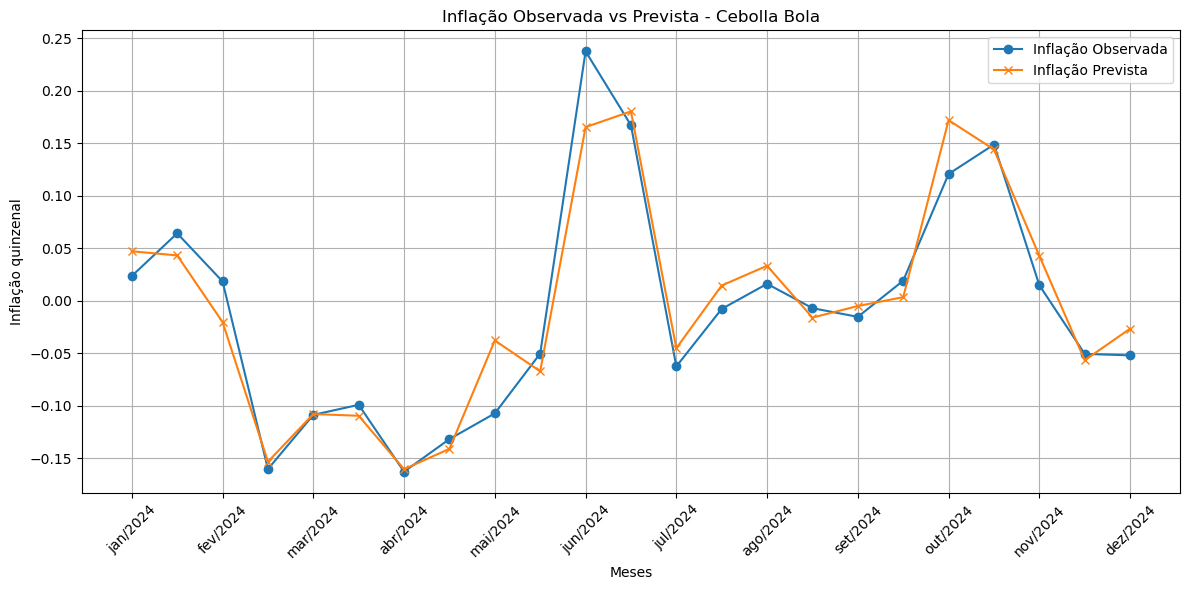

Gráfico salvo.



In [6]:
import numpy as np

# --- 10. gráfico observado vs previsto ---
print("\n--- 10. Gerando gráfico de resultados... ---")
df_plot = pd.DataFrame({"y": y_clean, "y_prev": modelo.predict(X_clean.fillna(0))}).reset_index(drop=True)
plt.figure(figsize=(12,6))
plt.plot(df_plot["y"], marker="o", label="Inflação Observada")
plt.plot(df_plot["y_prev"], marker="x", label="Inflação Prevista")
plt.title("Inflação Observada vs Prevista - Cebolla Bola")
plt.xlabel("Meses")
plt.ylabel("Inflação quinzenal")

# Definindo 12 ticks mensais
n_ticks = 12
xticks_pos = np.linspace(0, len(df_plot)-1, n_ticks, dtype=int)
xticks_labels = ["jan/2024", "fev/2024", "mar/2024", "abr/2024", "mai/2024", 
                 "jun/2024", "jul/2024", "ago/2024", "set/2024", "out/2024", 
                 "nov/2024", "dez/2024"]
plt.xticks(ticks=xticks_pos, labels=xticks_labels, rotation=45)

plt.legend()
plt.grid(True)
plt.tight_layout()
grafico_path = r"C:\Users\lucas\Downloads\Case Bradesco\grafico_inflacao_cebola_versaofinal.png"# <-- Alterar caminho
plt.savefig(grafico_path, dpi=300)
plt.show()
print("Gráfico salvo.\n")



================ DIAGNÓSTICOS ECONOMÉTRICOS ================

Teste de Autocorrelação:
Durbin-Watson: 2.197
Ljung-Box (p-valores):
   lb_pvalue
1   0.474281
2   0.410167
4   0.661878 

Teste de Normalidade (Jarque-Bera):
JB p-value: 0.4968

Teste de Raiz Unitária (ADF) - estacionariedade da inflação:
ADF Statistic: -1.739
p-value: 0.4109
Valores críticos: {'1%': -4.01203360058309, '5%': -3.1041838775510207, '10%': -2.6909873469387753}
Série não estacionária (não rejeita H0 de raiz unitária)

Erros robustos HAC (Newey-West):
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.922
Model:                            OLS   Adj. R-squared (uncentered):              0.915
Method:                 Least Squares   F-statistic:                              177.7
Date:                Mon, 13 Oct 2025   Prob (F-statistic):                    6.92e-14
Time:                        

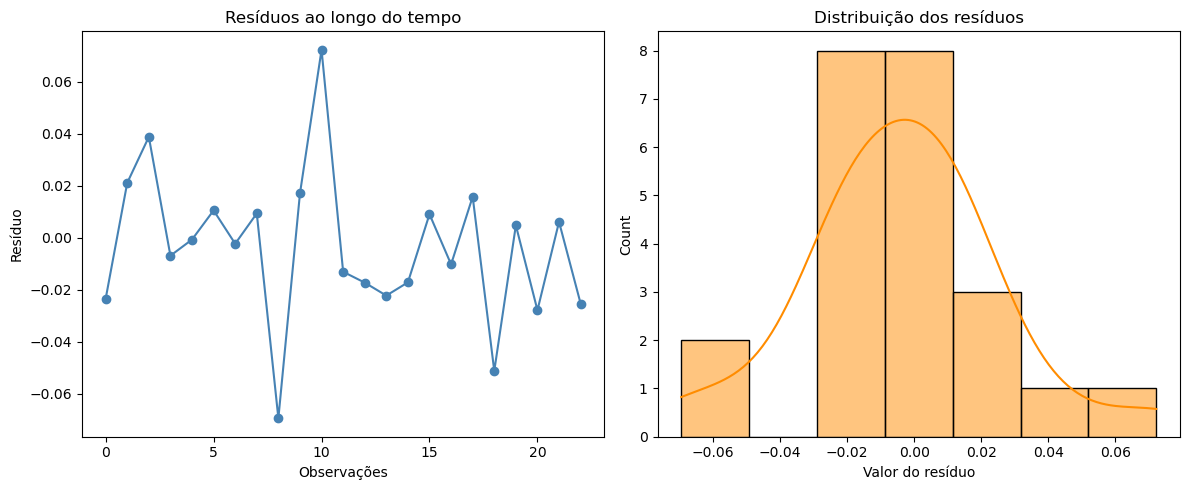

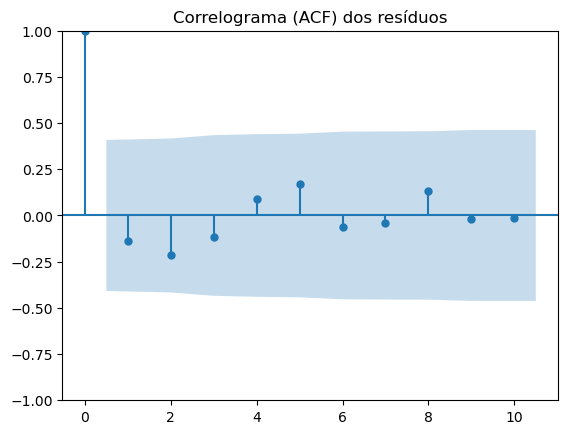

In [7]:
# --- 11. Diagnósticos econométricos (sem testes que exigem constante) ---

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

print("\n================ DIAGNÓSTICOS ECONOMÉTRICOS ================\n")

# --- Resíduos do modelo ---
resid = modelo.resid

# Autocorrelação dos erros
dw = durbin_watson(resid)
ljung = acorr_ljungbox(resid, lags=[1, 2, 4], return_df=True)
print("Teste de Autocorrelação:")
print(f"Durbin-Watson: {dw:.3f}")
print("Ljung-Box (p-valores):")
print(ljung[['lb_pvalue']], "\n")

# Normalidade dos resíduos
jb_test = jarque_bera(resid)
print("Teste de Normalidade (Jarque-Bera):")
print(f"JB p-value: {jb_test[1]:.4f}\n")

# Teste de Raiz Unitária (ADF)
print("Teste de Raiz Unitária (ADF) - estacionariedade da inflação:")
serie_y = pd.Series(y_clean).dropna()
adf_stat, adf_p, _, _, crit_values, _ = adfuller(serie_y)
print(f"ADF Statistic: {adf_stat:.3f}")
print(f"p-value: {adf_p:.4f}")
print(f"Valores críticos: {crit_values}")
if adf_p < 0.05:
    print("Série estacionária (rejeita H0 de raiz unitária)\n")
else:
    print("Série não estacionária (não rejeita H0 de raiz unitária)\n")

# Erros robustos HAC (Newey-West)
print("Erros robustos HAC (Newey-West):")
modelo_hac = modelo.get_robustcov_results(cov_type='HAC', maxlags=2)
print(modelo_hac.summary())

warnings.filterwarnings("ignore", category=FutureWarning)

# Visualizações dos resíduos
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(resid, marker='o', linestyle='-', color='steelblue')
plt.title('Resíduos ao longo do tempo')
plt.xlabel('Observações')
plt.ylabel('Resíduo')

plt.subplot(1,2,2)
sns.histplot(resid, kde=True, color='darkorange')
plt.title('Distribuição dos resíduos')
plt.xlabel('Valor do resíduo')
plt.tight_layout()
plt.show()

# Correlograma (ACF) dos resíduos
sm.graphics.tsa.plot_acf(resid, lags=10)
plt.title('Correlograma (ACF) dos resíduos')
plt.show()
